# Random Forest

## 1. Pengertian Random Forest

Random Forest adalah algoritma machine learning yang digunakan untuk klasifikasi dan regresi. Algoritma ini bekerja dengan menggabungkan banyak Decision Tree agar hasil prediksi menjadi lebih akurat dan stabil.

Setiap Decision Tree di dalam Random Forest akan menghasilkan prediksi masing-masing. Setelah itu, semua hasil prediksi digabungkan untuk menentukan keputusan akhir. Pada kasus klasifikasi, keputusan akhir ditentukan berdasarkan voting terbanyak.

Secara sederhana:

**Random Forest = kumpulan banyak Decision Tree yang digunakan bersama untuk membuat prediksi.**



## 2. Implementasi di KNIME

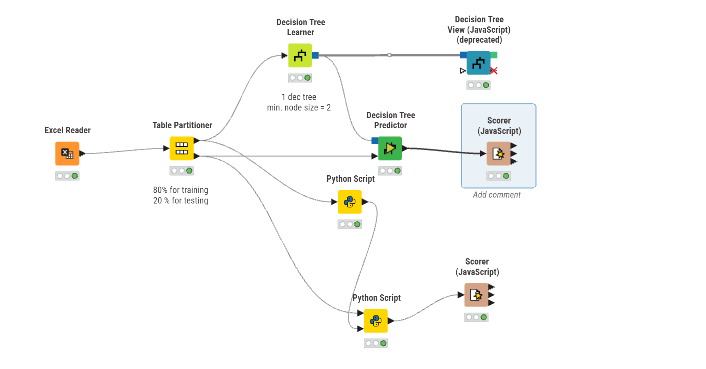

Pada workflow tersebut terdapat dua proses utama, yaitu:

1. Proses model Decision Tree
2. Proses model Random Forest menggunakan Python Script


### 2.1 Excel Reader

Node Excel Reader digunakan untuk membaca dataset dari file Excel ke dalam KNIME.


### 2.2 Table Partitioner

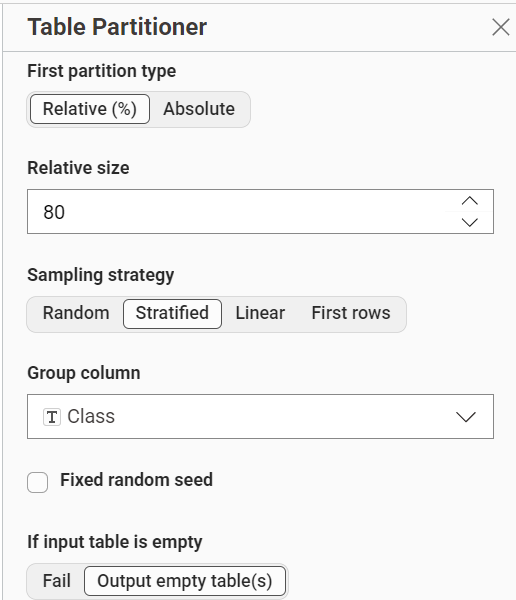

Node Table Partitioner digunakan untuk membagi dataset menjadi dua bagian, yaitu data training dan data testing.

Pada konfigurasi ini, data dibagi dengan perbandingan 80:20. Sebanyak 80% data digunakan sebagai data training untuk melatih model, sedangkan 20% data digunakan sebagai data testing untuk menguji performa model.

Pembagian data dilakukan dengan metode Stratified Sampling berdasarkan kolom Class. Metode ini menjaga agar proporsi setiap kelas tetap seimbang pada data training dan data testing.

Dengan pembagian ini, model dapat dilatih menggunakan sebagian besar data dan diuji menggunakan data yang belum pernah dipelajari sebelumnya.

### 2.3 Decision Tree Learner


Decision Tree Learner digunakan untuk membangun model pohon keputusan dari data training dengan target Class. Split criterion yang dipilih adalah Gain Ratio, sehingga fitur yang paling informatif akan digunakan untuk membagi data pada setiap cabang. Pada konfigurasi ini digunakan No pruning, artinya pohon tidak dipangkas dan akan dibentuk sesuai pola pada data training. Minimum records per node = 2, sehingga setiap node minimal memiliki 2 data agar dapat diproses. Number of records to store = 10.000 digunakan untuk menyimpan data yang diperlukan dalam visualisasi tree.

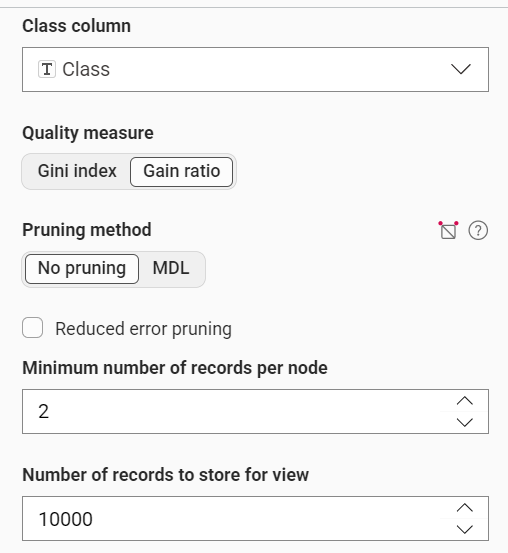

Hasil:

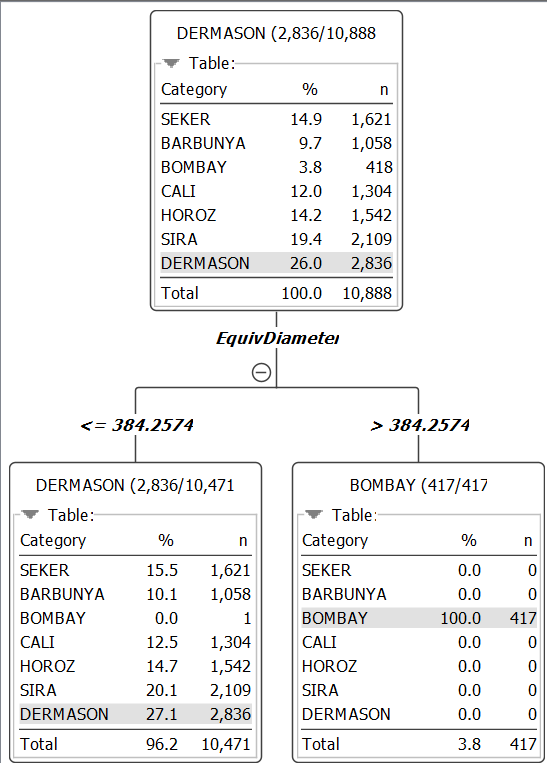


Hasil visualisasi Decision Tree menunjukkan bahwa node awal memprediksi kelas DERMASON karena kelas ini memiliki jumlah data paling banyak, yaitu 2.836 dari total 10.888 data atau sekitar 26%.

Pemisahan pertama dilakukan berdasarkan fitur EquivDiameter dengan batas nilai 384.2574. Jika nilai EquivDiameter <= 384.2574, data masuk ke cabang kiri dan mayoritas kelasnya tetap DERMASON dengan jumlah 2.836 dari 10.471 data. Pada cabang ini, data masih berisi beberapa kelas lain seperti SEKER, BARBUNYA, CALI, HOROZ, dan SIRA.

Jika nilai EquivDiameter > 384.2574, data masuk ke cabang kanan dan seluruh data pada cabang tersebut termasuk kelas BOMBAY, yaitu 417 dari 417 data. Hal ini menunjukkan bahwa fitur EquivDiameter sangat berpengaruh dalam memisahkan kelas BOMBAY dari kelas lainnya.

Secara singkat, tree ini menunjukkan bahwa ukuran EquivDiameter dapat menjadi pembeda utama, terutama untuk mengenali kelas BOMBAY, sedangkan data dengan ukuran lebih kecil masih perlu pemisahan lanjutan untuk membedakan kelas lainnya.

### 2.4 Decision Tree View

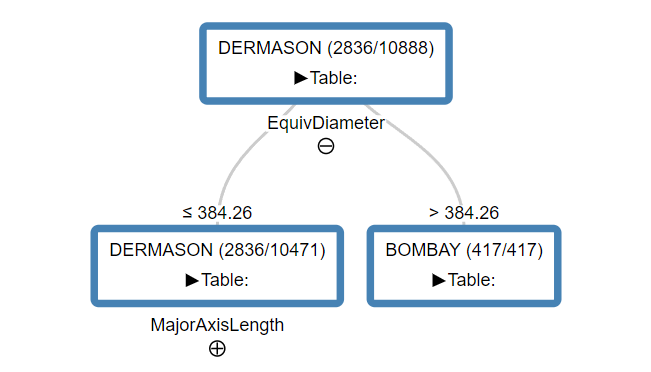


Hasil visualisasi Decision Tree menunjukkan bahwa node utama memprediksi kelas DERMASON dengan jumlah 2.836 dari 10.888 data Artinya, pada keseluruhan dataset, kelas DERMASON menjadi kelas yang paling dominan.

Pemisahan pertama dilakukan berdasarkan atribut EquivDiameter Jika nilai EquivDiameter ≤ 384.26, maka data masuk ke cabang kiri dan mayoritas hasilnya tetap diklasifikasikan sebagai DERMASON dengan jumlah 2.836 dari 10.471 data

Sedangkan jika nilai EquivDiameter > 384.26, maka data masuk ke cabang kanan dan seluruh data pada cabang tersebut diklasifikasikan sebagai BOMBAY, yaitu 417 dari 417 data

Dari hasil ini dapat disimpulkan bahwa atribut EquivDiameter sangat berpengaruh dalam membedakan kelas BOMBAY dari kelas lainnya. Data dengan nilai EquivDiameter yang lebih besar dari 384.26 cenderung masuk ke kelas BOMBAY, sedangkan data dengan nilai lebih kecil masih didominasi oleh kelas DERMASON dan perlu dipisahkan lagi menggunakan atribut lain seperti MajorAxisLength.

### 2.5 Decision Tree Predictor


Node Decision Tree Predictor digunakan untuk melakukan prediksi terhadap data testing menggunakan model Decision Tree yang sudah dilatih.

Node ini menerima dua input, yaitu:

- Model Decision Tree dari Decision Tree Learner
- Data testing dari Table Partitioner

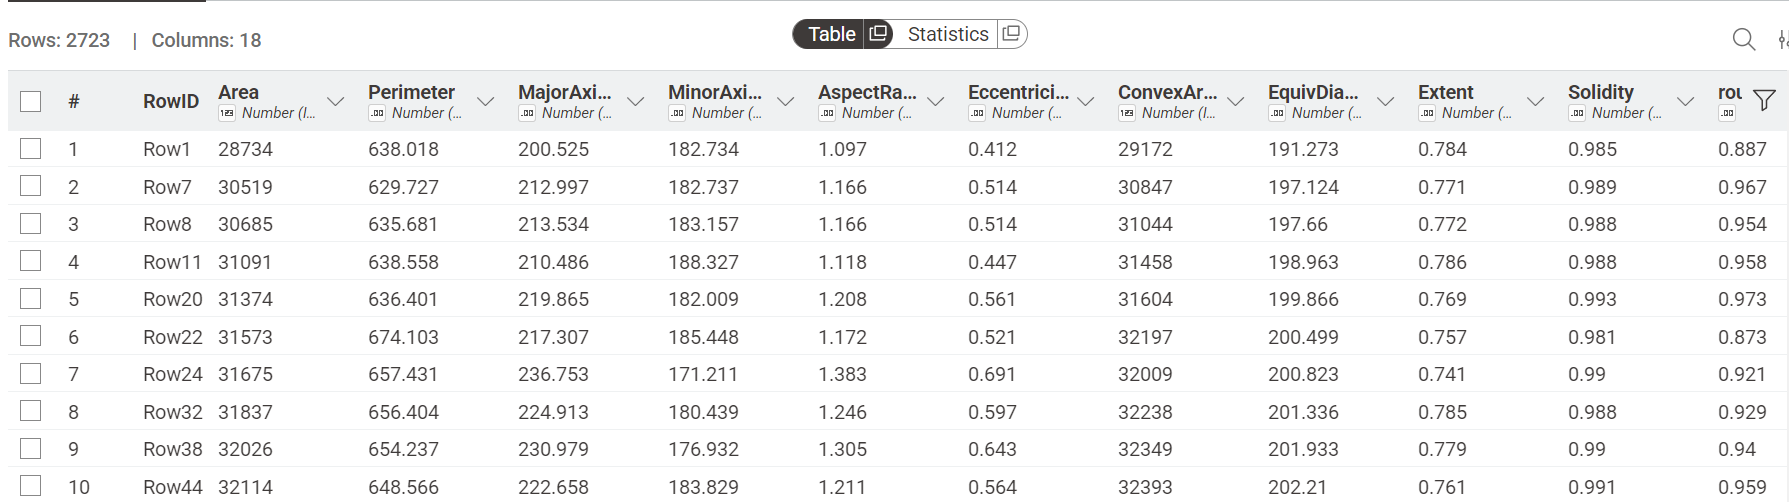


Hasil pada gambar menunjukkan output data dalam bentuk tabel dengan jumlah 2.723 baris dan 18 kolom. Data ini merupakan hasil pembagian dari node Table Partitioner, yaitu bagian data yang digunakan sebagai data testing.

Setiap baris mewakili satu data biji kacang, sedangkan setiap kolom berisi fitur atau atribut yang digunakan untuk proses prediksi. Beberapa fitur yang terlihat pada tabel yaitu Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio, Eccentricity, ConvexArea, EquivDiameter, Extent, dan Solidity.

Data testing ini nantinya digunakan untuk menguji model yang sudah dilatih sebelumnya. Model akan membaca nilai-nilai fitur tersebut, lalu menghasilkan prediksi kelas. Setelah itu, hasil prediksi akan dibandingkan dengan kelas asli untuk mengetahui seberapa baik performa model.

Jumlah 2.723 baris menunjukkan bahwa data ini adalah sebagian dari dataset utama yang dipisahkan untuk pengujian, sedangkan 18 kolom menunjukkan jumlah atribut yang digunakan dalam proses analisis dan prediksi.

### 2.6 Scorer (JavaScript)

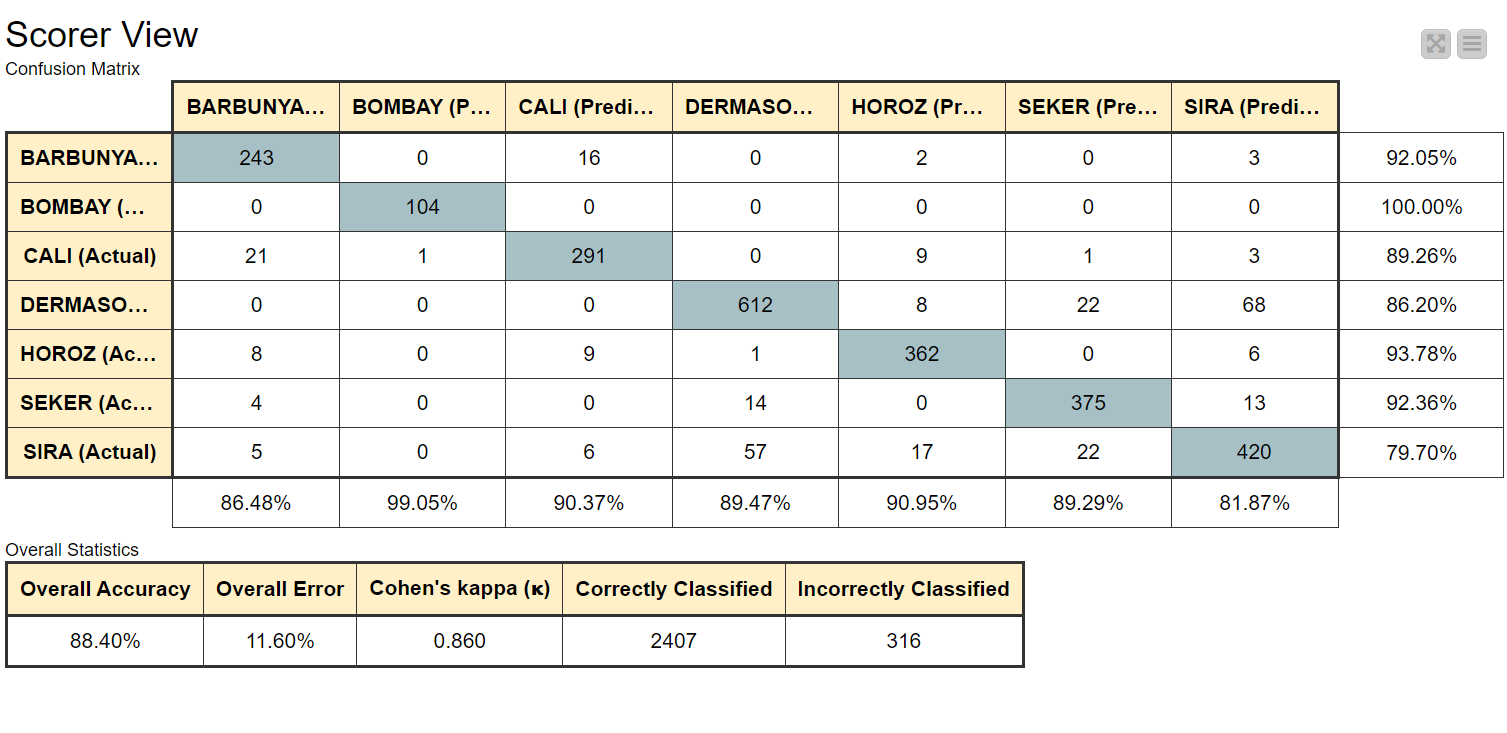

Hasil pada Scorer View menunjukkan bahwa model berhasil mendapatkan Overall Accuracy sebesar 88,40%. Artinya, dari total data testing, sebanyak 2.407 data berhasil diprediksi dengan benar, sedangkan 316 data masih salah klasifikasi.

Pada bagian Confusion Matrix, nilai yang berada pada garis diagonal menunjukkan jumlah data yang diprediksi benar. Beberapa kelas memiliki hasil yang sangat baik, seperti BOMBAY yang berhasil diprediksi benar seluruhnya, yaitu 104 dari 104 data. Kelas HOROZ, SEKER, dan BARBUNYA juga menunjukkan hasil prediksi yang cukup tinggi.

Namun, masih terdapat beberapa kesalahan prediksi pada kelas tertentu. Kesalahan paling terlihat pada kelas SIRA dan DERMASON, karena beberapa data dari kedua kelas tersebut saling tertukar dalam hasil prediksi. Hal ini kemungkinan terjadi karena kedua kelas memiliki karakteristik fitur yang cukup mirip.

Nilai Overall Error sebesar 11,60% menunjukkan persentase data yang salah diprediksi oleh model. Sementara itu, nilai Cohen’s Kappa sebesar 0,860 menunjukkan bahwa hasil prediksi model sudah termasuk sangat baik.

Secara keseluruhan, model Decision Tree sudah mampu melakukan klasifikasi dengan cukup baik, karena sebagian besar data testing berhasil diprediksi sesuai dengan kelas aslinya.

### 2.7 Pyhton Script

Node Python Script pertama digunakan untuk membuat model Random Forest menggunakan data training. Proses ini dilakukan dengan bantuan kode Python.

Berikut Kode dan penjelasannya:

```python
import os
import joblib
import pandas as pd
import knime.scripting.io as knio

from sklearn.ensemble import RandomForestClassifier

```
Bagian ini digunakan untuk memanggil library yang dibutuhkan.

* os digunakan untuk membuat path file model.
* joblib digunakan untuk menyimpan model Random Forest.
* pandas digunakan untuk mengolah data dalam bentuk dataframe.
* knime.scripting.io digunakan agar Python bisa membaca input dan mengirim output di KNIME.
* RandomForestClassifier digunakan untuk membuat model Random Forest.

```python
train_df = knio.input_tables[0].to_pandas()
```

Bagian ini mengambil data training dari input node Python Script di KNIME, lalu mengubahnya menjadi dataframe pandas.

```python
target_col = "Class"
```

Menentukan kolom target yang akan diprediksi oleh model. Pada dataset Dry Bean, kolom targetnya adalah Class, yaitu jenis atau kelas dari biji kacang.

```python
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
```

Bagian ini memisahkan data menjadi dua bagian.

* `X_train` berisi fitur atau atribut yang digunakan untuk membuat prediksi.
* `y_train` berisi target atau label yang akan diprediksi, yaitu kolom Class.

Dengan pemisahan ini, model dapat belajar dari fitur untuk mengenali kelas pada data.

```python
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
```
Bagian ini digunakan untuk membuat model Random Forest.

* `n_estimators=50` berarti model menggunakan 50 pohon keputusan.
* `random_state=42` digunakan agar hasil training tetap konsisten saat dijalankan ulang.
* `n_jobs=-1` digunakan agar proses training memakai semua core CPU yang tersedia.

```python
rf_model.fit(X_train, y_train)
```

Bagian ini digunakan untuk melatih model Random Forest menggunakan data training. Model akan mempelajari pola dari fitur pada `X_train` dan target pada `y_train`.

```python
model_path = os.path.abspath("random_forest_dry_bean_model.joblib")
joblib.dump(rf_model, model_path)
```

Menyimpan model yang sudah dilatih ke dalam file bernama:

`random_forest_dry_bean_model.joblib`

File ini nantinya dapat digunakan kembali pada Python Script berikutnya untuk melakukan prediksi tanpa perlu melatih model dari awal.

```python
output_df = pd.DataFrame({
    "model_path": [model_path],
    "target_column": [target_col],
    "number_of_trees": [50]
})
```

Bagian ini membuat tabel output yang berisi informasi model.
Isi Output:

| Kolom | Keterangan |
|---|---|
| model_path | Lokasi file model yang sudah disimpan |
| target_column | Nama kolom target, yaitu Class |
| number_of_trees | Jumlah tree yang digunakan, yaitu 50 |


```python
knio.output_tables[0] = knio.Table.from_pandas(output_df)
```

Bagian ini mengirim tabel output dari Python ke KNIME.

Output ini nantinya dapat digunakan oleh Python Script berikutnya untuk mengetahui lokasi model Random Forest yang sudah disimpan.

### 2.8 Python Script

Python Script kedua berfungsi untuk melakukan prediksi menggunakan model Random Forest yang sudah dibuat sebelumnya.

Node ini memiliki dua input karena membutuhkan data testing dari Table Partitioner dan informasi model dari Python Script pertama. Data testing digunakan sebagai data yang akan diprediksi, sedangkan output dari Python Script pertama digunakan untuk memanggil model Random Forest yang sudah dilatih.

Hasil dari node ini adalah tabel data testing yang sudah memiliki kolom prediksi. Hasil tersebut kemudian diteruskan ke Scorer untuk mengetahui performa model Random Forest.




Berikut kode dan penjelasannya:


Kode ini digunakan untuk menjalankan proses prediksi Random Forest. Model yang sudah dibuat pada Python Script pertama akan dipanggil kembali, lalu digunakan untuk memprediksi data testing.


```python
import joblib
import pandas as pd
import knime.scripting.io as knio

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
```

Bagian ini digunakan untuk memanggil library yang dibutuhkan.

* `joblib` digunakan untuk membuka model Random Forest yang sudah disimpan.
* `pandas` digunakan untuk mengolah data dalam bentuk tabel.
* `knime.scripting.io` digunakan untuk mengambil input dan mengirim output di KNIME.
* Library dari `sklearn.metrics` digunakan untuk menghitung hasil evaluasi model.

```python
input_1 = knio.input_tables[0].to_pandas()
input_2 = knio.input_tables[1].to_pandas()
```

Bagian ini mengambil dua input dari KNIME. Python Script kedua memiliki dua input karena membutuhkan data testing dan informasi model dari Python Script pertama.

```python
if "model_path" in input_1.columns:
    model_info = input_1
    test_df = input_2
elif "model_path" in input_2.columns:
    model_info = input_2
    test_df = input_1
```

Bagian ini digunakan untuk mendeteksi otomatis mana input yang berisi informasi model dan mana input yang berisi data testing.

Kolom model_path digunakan sebagai penanda bahwa data tersebut adalah output dari Python Script pertama.

```python
model_path = model_info.iloc[0]["model_path"]
```

Bagian ini mengambil lokasi file model Random Forest yang sudah disimpan sebelumnya. File model tersebut akan dipanggil kembali agar bisa digunakan untuk prediksi.

```python
if "target_column" in model_info.columns:
    target_col = model_info.iloc[0]["target_column"]
else:
    target_col = "Class"
```

Menentukan kolom target yang akan diprediksi.

Jika informasi target tersedia dari Python Script pertama, maka target tersebut digunakan. Jika tidak ada, kode akan memakai Class sebagai target default.

```python
rf_model = joblib.load(model_path)
```

Bagian ini digunakan untuk membuka model Random Forest yang sudah dilatih dan disimpan dalam file `.joblib.`


```python
y_test = test_df[target_col]
```
Bagian ini mengambil kolom target asli dari data testing. Target asli ini nantinya digunakan untuk dibandingkan dengan hasil prediksi model.


```python
X_test = test_df[feature_cols]
```

Bagian ini mengambil kolom fitur yang digunakan untuk prediksi. Fitur yang dipakai disamakan dengan fitur saat model dilatih.

```python
y_pred = rf_model.predict(X_test)
```

Bagian ini adalah proses utama dari Python Script kedua. Model Random Forest digunakan untuk memprediksi kelas dari data testing.

```python
output_df = test_df.copy()
output_df["Prediction (Class)"] = y_pred
```

Membuat Output Prediksi. Tabel tersebut berisi data testing asli dan tambahan kolom Prediction (Class) yang berisi hasil prediksi Random Forest.

```python
accuracy = accuracy_score(y_test, y_pred)
```

Bagian ini menghitung akurasi model berdasarkan perbandingan antara target asli dan hasil prediksi.

```python
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
```

Bagian ini menampilkan confusion matrix dan classification report di console Python.

```python
knio.output_tables[0] = knio.Table.from_pandas(output_df)
```

Bagian terakhir ini mengirim hasil prediksi kembali ke KNIME. Output dari node ini kemudian dapat diteruskan ke node Scorer untuk melihat hasil evaluasi Random Forest secara lebih jelas.


### 2.9 Scorer (JavaScript)

Node Scorer terakhir digunakan untuk mengevaluasi hasil prediksi Random Forest. Hasil evaluasi ini dapat dibandingkan dengan hasil Decision Tree untuk melihat model mana yang memiliki performa lebih baik.


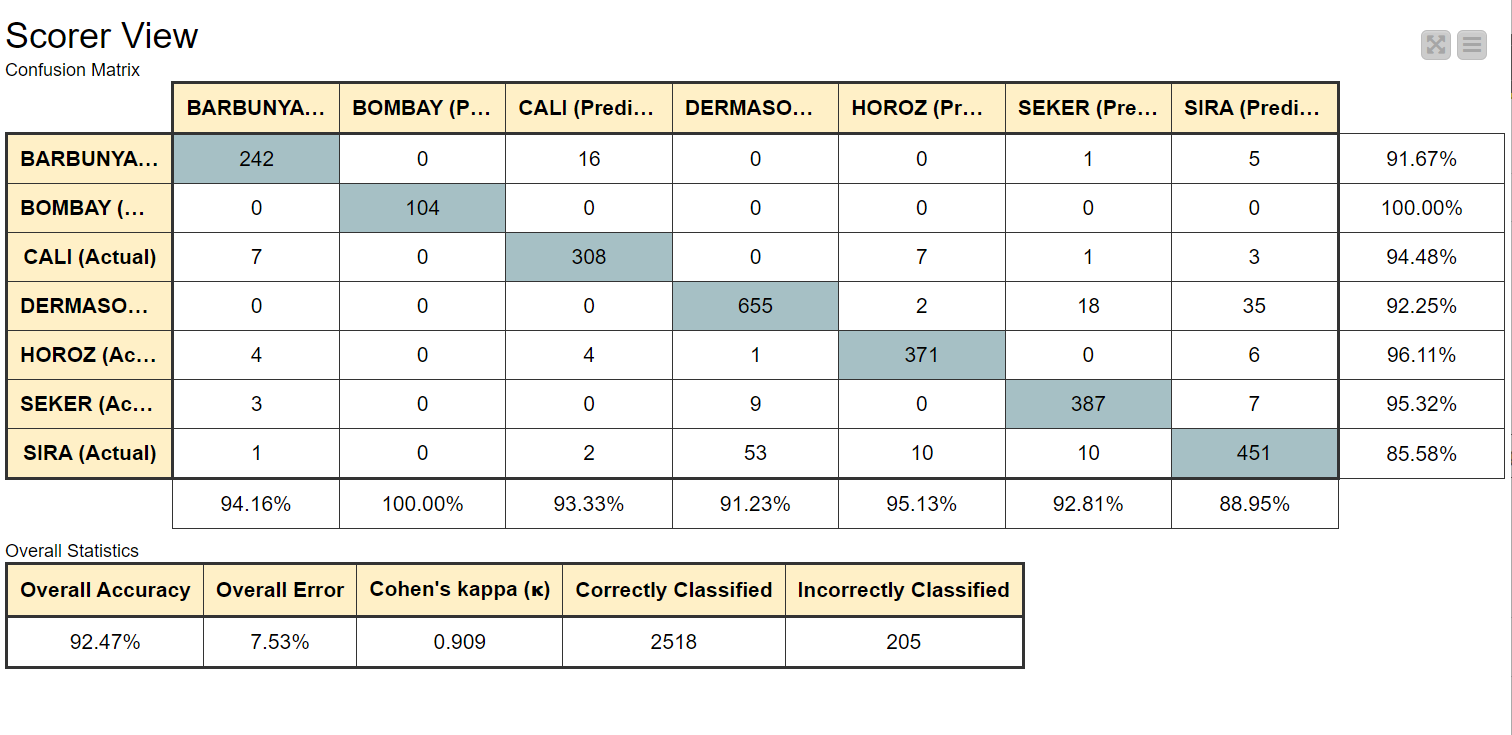


Berdasarkan evaluasi pada node Scorer, model Random Forest mendapatkan akurasi sebesar 92,47%. Dari total data testing, terdapat 2.518 data yang berhasil diklasifikasikan dengan benar dan 205 data yang masih salah klasifikasi.

Pada bagian confusion matrix, angka pada diagonal menunjukkan prediksi yang benar untuk setiap kelas. Kelas BOMBAY memiliki hasil paling baik karena seluruh datanya berhasil diprediksi dengan benar, yaitu 104 data.

Nilai Overall Error sebesar 7,53% menunjukkan bahwa tingkat kesalahan model cukup kecil. Selain itu, nilai Cohen’s Kappa sebesar 0,909 menandakan bahwa performa model termasuk sangat baik.


## 3. Kesimpulan Hasil Node

### 1. Proses Model Decision Tree

Pada proses Decision Tree, data dibaca menggunakan Excel Reader, kemudian dibagi menjadi data training dan data testing melalui Table Partitioner. Data training digunakan pada node Decision Tree Learner untuk membangun model pohon keputusan. Setelah model terbentuk, hasilnya dapat dilihat melalui Decision Tree View dan digunakan untuk memprediksi data testing pada Decision Tree Predictor.

Hasil prediksi kemudian dievaluasi menggunakan Scorer. Berdasarkan hasil evaluasi, model Decision Tree memperoleh accuracy sebesar 88,40%, dengan 2.407 data berhasil diprediksi benar dan 316 data salah klasifikasi. Hasil ini menunjukkan bahwa Decision Tree sudah cukup baik dalam melakukan klasifikasi, tetapi masih terdapat beberapa kesalahan prediksi pada kelas tertentu.

### 2. Proses Model Random Forest Menggunakan Python Script

Pada proses Random Forest, model dibuat menggunakan Python Script. Python Script pertama digunakan untuk melatih model Random Forest dari data training, lalu model disimpan agar dapat digunakan kembali. Python Script kedua digunakan untuk memanggil model tersebut dan melakukan prediksi pada data testing.

Hasil prediksi Random Forest kemudian dievaluasi menggunakan Scorer. Berdasarkan hasil evaluasi, model Random Forest memperoleh accuracy sebesar 92,47%, dengan 2.518 data berhasil diprediksi benar dan 205 data salah klasifikasi. Hasil ini menunjukkan bahwa Random Forest mampu memberikan prediksi yang lebih baik dan lebih stabil.

## 4. Perbandingan Decision Tree dan Random Forest

| Model | Accuracy | Error | Correctly Classified | Incorrectly Classified | Cohen's Kappa |
|---|---|:---:|:---:|:---:|:---:|
| Decision Tree | 88,40% | 11,60% | 2.407 | 316 | 0,860 |
| Random Forest | 92,47% | 7,53% | 2.518 | 205 | 0,909 |

Berdasarkan tabel perbandingan, Random Forest memiliki performa lebih baik dibandingkan Decision Tree. Random Forest menghasilkan accuracy yang lebih tinggi, error yang lebih rendah, dan jumlah data salah klasifikasi yang lebih sedikit.

Decision Tree lebih mudah dipahami karena bentuknya berupa satu pohon keputusan. Namun, Random Forest lebih unggul dalam hasil prediksi karena menggunakan banyak pohon keputusan sehingga model menjadi lebih stabil dan akurat.

Secara keseluruhan, model Random Forest menggunakan Python Script menjadi model yang lebih baik.